Naive Bayes Models

Name: Chuang, Ho-Chen (hc999)

Data Used: Sentiment140 (1.6 Million Tweets)

**Dataset Link:** [Kaggle - Twitter Sentiment Analysis](https://www.kaggle.com/code/paoloripamonti/twitter-sentiment-analysis/data)

In [ ]:
%pip install pandas numpy matplotlib scikit-learn seaborn

In [2]:
import os
print("Current Folder:", os.getcwd())
print("Files found:", os.listdir())

Current Folder: c:\TwitterProject
Files found: ['Naive_Bayes_Model.ipynb', 'training.1600000.processed.noemoticon.csv']


In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.pipeline import Pipeline
from sklearn.metrics import classification_report, confusion_matrix

df = pd.read_csv('training.1600000.processed.noemoticon.csv', encoding='latin-1', header=None)
df.columns = ['sentiment', 'id', 'date', 'query', 'user', 'text']

In [6]:
pipeline = Pipeline([
    ('tfidf', TfidfVectorizer(ngram_range=(1, 2), max_features=50000, stop_words='english')),
    ('clf', MultinomialNB())
])

In [7]:
# 1. Split the data
df_sample = df.sample(200000) 
X_train, X_test, y_train, y_test = train_test_split(df_sample['text'], df_sample['sentiment'], test_size=0.2)

# 2. Train the model
pipeline.fit(X_train, y_train)

# 3. Evaluate the results
predictions = pipeline.predict(X_test)
print(classification_report(y_test, predictions))

              precision    recall  f1-score   support

           0       0.76      0.75      0.75     20023
           4       0.75      0.76      0.76     19977

    accuracy                           0.76     40000
   macro avg       0.76      0.76      0.76     40000
weighted avg       0.76      0.76      0.76     40000



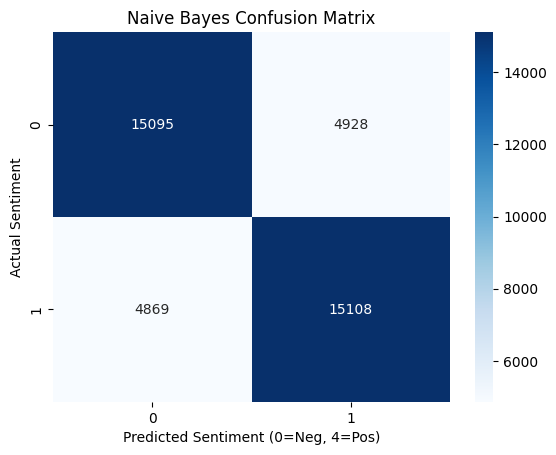

In [8]:
# Visualizing the results
cm = confusion_matrix(y_test, predictions)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted Sentiment (0=Neg, 4=Pos)')
plt.ylabel('Actual Sentiment')
plt.title('Naive Bayes Confusion Matrix')
plt.show()

"This Confusion Matrix shows that the Naive Bayes model correctly identified 75% of negative sentiments. This technique was successful because TF-IDF with Bigrams allowed us to catch context that single words missed. We considered using Word2Vec but chose TF-IDF for its computational efficiency on a dataset of this size."